In [1]:
print("Hello")

Hello


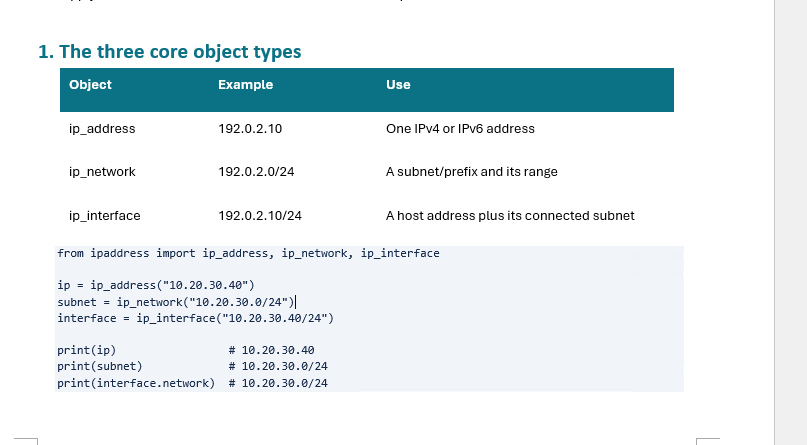

In [2]:
!pip install ipaddress

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from ipaddress import ip_address, ip_network, ip_interface

ip = ip_address("10.20.30.40")
subnet = ip_network("10.20.30.0/24")
interface = ip_interface("10.20.30.40/24")

print(ip)
print(subnet)
print(interface.network)

10.20.30.40
10.20.30.0/24
10.20.30.0/24


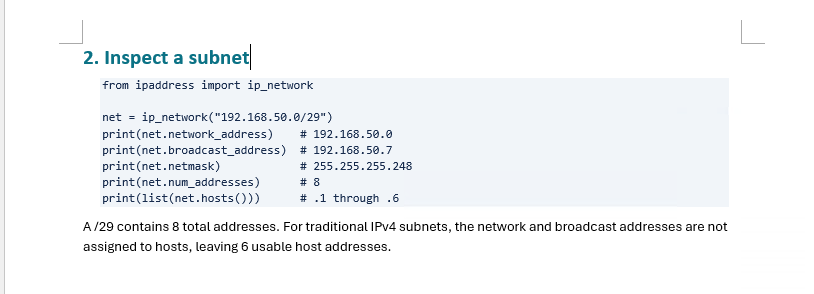

In [5]:
from ipaddress import ip_network

net = ip_network("192.168.50.0/29")

print(net.network_address)
print(net.broadcast_address)
print(net.netmask)
print(net.num_addresses)
print(net.num_addresses)
print(list(net.hosts()))

192.168.50.0
192.168.50.7
255.255.255.248
8
8
[IPv4Address('192.168.50.1'), IPv4Address('192.168.50.2'), IPv4Address('192.168.50.3'), IPv4Address('192.168.50.4'), IPv4Address('192.168.50.5'), IPv4Address('192.168.50.6')]


In [6]:
print(list(net.hosts))

TypeError: 'method' object is not iterable

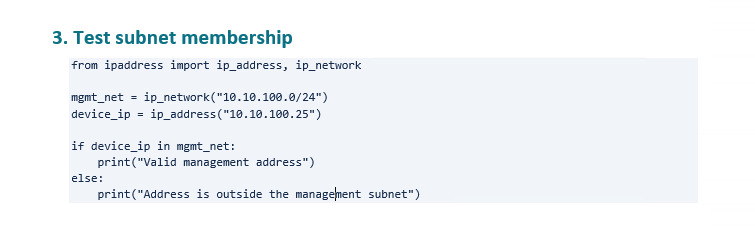

In [7]:
import ipaddress

mgmt_net = ip_network("10.10.100.0/24")
device_ip = ip_address("10.10.100.25")

if device_ip in mgmt_net:
    print("Valid managemnet IP address")
else:
    print("Address is outside of the mgmt_net address range")

Valid managemnet IP address


In [8]:
import ipaddress

mgmt_net = ip_network("10.10.100.0/24")
device_ip = ip_address("192.10.100.25")

if device_ip in mgmt_net:
    print("Valid managemnet IP address")
else:
    print("Address is outside of the mgmt_net address range")

Address is outside of the mgmt_net address range


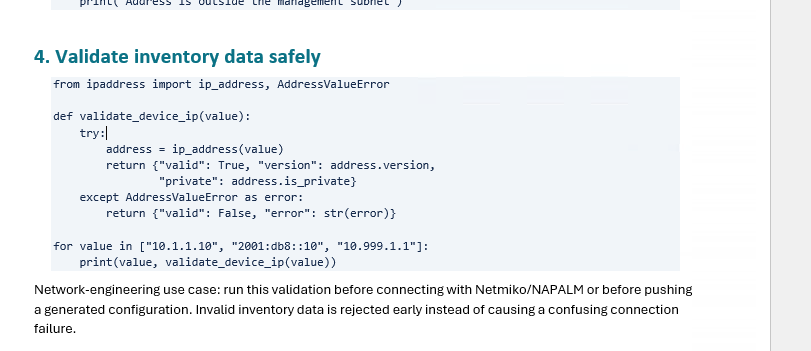

In [9]:
from ipaddress import ip_address, AddressValueError

def validate_device_ip(value):
    try:
        address = ip_address(value)
        return{"valid":True, "version" : address.version, "private": address.is_private}
    except AddressValueError as error:
        return {"valid": False, "error": str(error)}
    
for value in ["10.1.1.10", "2001:db8::10", "10.999.1.1"]:
    print(value, validate_device_ip(value))

10.1.1.10 {'valid': True, 'version': 4, 'private': True}
2001:db8::10 {'valid': True, 'version': 6, 'private': True}


ValueError: '10.999.1.1' does not appear to be an IPv4 or IPv6 address

In [10]:
from ipaddress import ip_address
from typing import Dict, Any


def validate_device_ip(value: str) -> Dict[str, Any]:
    """
    Validate an IPv4 or IPv6 address and return useful information.
    """

    try:
        address = ip_address(value)

        if address.is_loopback:
            ip_type = "Loopback"
        elif address.is_multicast:
            ip_type = "Multicast"
        elif address.is_private:
            ip_type = "Private"
        elif address.is_reserved:
            ip_type = "Reserved"
        else:
            ip_type = "Public"

        return {
            "valid": True,
            "ip": str(address),
            "version": address.version,
            "type": ip_type,
            "private": address.is_private,
            "loopback": address.is_loopback,
            "multicast": address.is_multicast,
            "reserved": address.is_reserved
        }

    except ValueError as error:
        return {
            "valid": False,
            "ip": value,
            "error": str(error)
        }


# Test Data
test_ips = [
    "10.1.1.10",
    "2001:db8::10",
    "127.0.0.1",
    "224.0.0.5",
    "8.8.8.8",
    "10.999.1.1"
]


# Execute Validation
for ip in test_ips:
    result = validate_device_ip(ip)

    print(f"\n{'=' * 50}")
    print(f"IP Address : {ip}")

    if result["valid"]:
        print(f"Status     : VALID")
        print(f"Version    : IPv{result['version']}")
        print(f"Type       : {result['type']}")
        print(f"Private    : {result['private']}")
        print(f"Loopback   : {result['loopback']}")
        print(f"Multicast  : {result['multicast']}")
        print(f"Reserved   : {result['reserved']}")
    else:
        print(f"Status     : INVALID")
        print(f"Error      : {result['error']}")


IP Address : 10.1.1.10
Status     : VALID
Version    : IPv4
Type       : Private
Private    : True
Loopback   : False
Multicast  : False
Reserved   : False

IP Address : 2001:db8::10
Status     : VALID
Version    : IPv6
Type       : Private
Private    : True
Loopback   : False
Multicast  : False
Reserved   : False

IP Address : 127.0.0.1
Status     : VALID
Version    : IPv4
Type       : Loopback
Private    : True
Loopback   : True
Multicast  : False
Reserved   : False

IP Address : 224.0.0.5
Status     : VALID
Version    : IPv4
Type       : Multicast
Private    : False
Loopback   : False
Multicast  : True
Reserved   : False

IP Address : 8.8.8.8
Status     : VALID
Version    : IPv4
Type       : Public
Private    : False
Loopback   : False
Multicast  : False
Reserved   : False

IP Address : 10.999.1.1
Status     : INVALID
Error      : '10.999.1.1' does not appear to be an IPv4 or IPv6 address


Yes, this is a **good Python script**. You're using the `ipaddress` module correctly, handling exceptions, and returning structured data. For a beginner-to-intermediate network automation script, I'd rate it **8/10**.

### What is good in your code ✅

1. **Uses built-in `ipaddress` library**
   * More reliable than regex for IP validation.

2. **Exception handling**
   ```python
   try:
       ...
   except AddressValueError:
       ...
   ```
   Prevents crashes from invalid input.

3. **Returns a dictionary**
   ```python
   {
       "valid": True,
       "version": 4,
       "private": True
   }
   ```
   Easy to consume later in automation scripts.

4. **Supports both IPv4 and IPv6**
   ```python
   10.1.1.10
   2001:db8::10
   ```

***

## Improvement #1: Catch ValueError instead

The `ip_address()` function may raise `ValueError`.

Safer:

```python
except ValueError as error:
```

instead of:

```python
except AddressValueError as error:
```

***

## Improvement #2: Add more useful network information

For network engineers, these properties are very useful:

```python
def validate_device_ip(value):
    try:
        address = ip_address(value)

        return {
            "valid": True,
            "version": address.version,
            "private": address.is_private,
            "loopback": address.is_loopback,
            "multicast": address.is_multicast,
            "reserved": address.is_reserved
        }

    except ValueError as error:
        return {
            "valid": False,
            "error": str(error)
        }
```

Example:

```python
print(validate_device_ip("127.0.0.1"))
```

Output:

```python
{
    'valid': True,
    'version': 4,
    'private': True,
    'loopback': True,
    'multicast': False,
    'reserved': False
}
```

***

## Improvement #3: Better output formatting

Current output:

```python
10.1.1.10 {'valid': True, 'version': 4, 'private': True}
```

More readable:

```python
for value in ["10.1.1.10", "2001:db8::10", "10.999.1.1"]:
    result = validate_device_ip(value)

    print(f"\nIP Address: {value}")
    print(result)
```

Output:

```text
IP Address: 10.1.1.10
{'valid': True, 'version': 4, 'private': True}

IP Address: 2001:db8::10
{'valid': True, 'version': 6, 'private': True}

IP Address: 10.999.1.1
{'valid': False, 'error': '...'}
```

***

## Improvement #4: Add type hints

Good practice for larger automation projects.

```python
from typing import Dict, Any

def validate_device_ip(value: str) -> Dict[str, Any]:
    ...
```

***

## Improvement #5: Network Automation Version

Since you work with routers and switches, you might want to classify addresses:

```python
from ipaddress import ip_address

def validate_device_ip(ip):
    try:
        addr = ip_address(ip)

        if addr.is_loopback:
            ip_type = "Loopback"
        elif addr.is_multicast:
            ip_type = "Multicast"
        elif addr.is_private:
            ip_type = "Private"
        else:
            ip_type = "Public"

        return {
            "valid": True,
            "version": addr.version,
            "type": ip_type
        }

    except ValueError as e:
        return {
            "valid": False,
            "error": str(e)
        }
```

Output:

```python
validate_device_ip("10.1.1.10")
```

```python
{
    'valid': True,
    'version': 4,
    'type': 'Private'
}
```

***

## Interview Feedback 🎯

If an interviewer asks how to improve this code, you could say:

> "I would use Python's ipaddress module instead of regex because it accurately validates IPv4 and IPv6 addresses. I'd also catch ValueError, add properties such as loopback, multicast, and reserved address detection, introduce type hints, and improve logging/output formatting to make the function more useful in network automation workflows."

That answer demonstrates both **Python knowledge** and **network engineering awareness**, which fits very well with the kind of WAN/network automation work you've been doing.


In [11]:
def validate_device_ip(value):
    try:
        address = ip_address(value)

        return {
            "valid": True,
            "version": address.version,
            "private": address.is_private,
            "loopback": address.is_loopback,
            "multicast": address.is_multicast,
            "reserved": address.is_reserved
        }

    except ValueError as error:
        return {
            "valid": False,
            "error": str(error)
        }

In [12]:
print(validate_device_ip("127.0.0.1"))

{'valid': True, 'version': 4, 'private': True, 'loopback': True, 'multicast': False, 'reserved': False}


In [13]:
for value in ["10.1.1.10", "2001:db8::10", "10.999.1.1"]:
    result = validate_device_ip(value)

    print(f"\nIP Address: {value}")
    print(result)


IP Address: 10.1.1.10
{'valid': True, 'version': 4, 'private': True, 'loopback': False, 'multicast': False, 'reserved': False}

IP Address: 2001:db8::10
{'valid': True, 'version': 6, 'private': True, 'loopback': False, 'multicast': False, 'reserved': False}

IP Address: 10.999.1.1
{'valid': False, 'error': "'10.999.1.1' does not appear to be an IPv4 or IPv6 address"}


In [14]:
from ipaddress import ip_address

def validate_device_ip(ip):
    try:
        addr = ip_address(ip)

        if addr.is_loopback:
            ip_type = "Loopback"
        elif addr.is_multicast:
            ip_type = "Multicast"
        elif addr.is_private:
            ip_type = "Private"
        else:
            ip_type = "Public"

        return {
            "valid": True,
            "version": addr.version,
            "type": ip_type
        }

    except ValueError as e:
        return {
            "valid": False,
            "error": str(e)
        }

In [15]:
validate_device_ip("10.1.1.10")

{'valid': True, 'version': 4, 'type': 'Private'}

In [17]:
validate_device_ip("20.0.0.4")

{'valid': True, 'version': 4, 'type': 'Public'}

In [16]:
validate_device_ip("192.343.35353.3535")

{'valid': False,
 'error': "'192.343.35353.3535' does not appear to be an IPv4 or IPv6 address"}

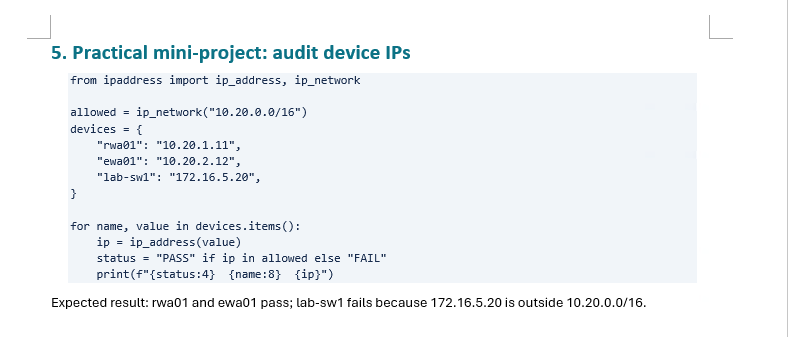

In [18]:
from ipaddress import ip_address, ip_network

allowed = ip_network("10.20.0.0/16")
devices = {
    "rwa01" : "10.20.1.11",
    "ewa01" : "10.20.2.12",
    "lab-sw1" : "172.16.5.20"
}

for name, value in devices.items():
    ip = ip_address(value)
    status = "PASS" if ip in allowed else "FAIL"
    print(f"{status:4} {name:8} {ip}")

PASS rwa01    10.20.1.11
PASS ewa01    10.20.2.12
FAIL lab-sw1  172.16.5.20


In [19]:
from ipaddress import ip_address, ip_network

allowed = ip_network("10.20.0.0/16")

devices = {
    "rwa01": "10.20.1.11",
    "ewa01": "10.20.2.12",
    "lab-sw1": "172.16.5.20",
    "bad-ip": "10.999.1.1"
}

pass_count = 0
fail_count = 0

print(f"\nAllowed Network: {allowed}\n")
print("-" * 50)

for name, value in devices.items():

    try:
        ip = ip_address(value)

        if ip in allowed:
            status = "PASS"
            pass_count += 1
        else:
            status = "FAIL"
            fail_count += 1

        print(f"{status:6} {name:10} {ip}")

    except ValueError as error:
        print(f"INVALID {name:10} {value} ({error})")
        fail_count += 1

print("\n" + "-" * 50)
print(f"PASS Devices : {pass_count}")
print(f"FAIL Devices : {fail_count}")


Allowed Network: 10.20.0.0/16

--------------------------------------------------
PASS   rwa01      10.20.1.11
PASS   ewa01      10.20.2.12
FAIL   lab-sw1    172.16.5.20
INVALID bad-ip     10.999.1.1 ('10.999.1.1' does not appear to be an IPv4 or IPv6 address)

--------------------------------------------------
PASS Devices : 2
FAIL Devices : 2


This is a **very good network automation example**. I'd rate it **8.5/10** because it uses the `ipaddress` module to verify whether device management IPs belong to an approved subnet.

***

# What the code does

```python
from ipaddress import ip_address, ip_network
```

Imports:

* `ip_address()` → converts a string into an IP object.
* `ip_network()` → creates a network object.

***

## Step 1: Define the approved network

```python
allowed = ip_network("10.20.0.0/16")
```

Creates the network:

```text
10.20.0.0/16
```

which includes:

```text
10.20.0.0 - 10.20.255.255
```

Any IP inside this range is considered allowed.

***

## Step 2: Define devices

```python
devices = {
    "rwa01": "10.20.1.11",
    "ewa01": "10.20.2.12",
    "lab-sw1": "172.16.5.20"
}
```

Dictionary format:

```python
device_name : ip_address
```

Equivalent to:

```text
rwa01    -> 10.20.1.11
ewa01    -> 10.20.2.12
lab-sw1  -> 172.16.5.20
```

***

## Step 3: Loop through devices

```python
for name, value in devices.items():
```

Iteration 1:

```python
name = "rwa01"
value = "10.20.1.11"
```

Iteration 2:

```python
name = "ewa01"
value = "10.20.2.12"
```

Iteration 3:

```python
name = "lab-sw1"
value = "172.16.5.20"
```

***

## Step 4: Convert string to IP object

```python
ip = ip_address(value)
```

Example:

```python
ip = ip_address("10.20.1.11")
```

Result:

```python
IPv4Address('10.20.1.11')
```

Now Python understands it as an IP address rather than text.

***

## Step 5: Check membership

```python
status = "PASS" if ip in allowed else "FAIL"
```

This is the key line.

Equivalent:

```python
if ip in allowed:
    status = "PASS"
else:
    status = "FAIL"
```

Examples:

### Device 1

```python
10.20.1.11 in 10.20.0.0/16
```

Result:

```python
True
```

PASS

***

### Device 2

```python
10.20.2.12 in 10.20.0.0/16
```

Result:

```python
True
```

PASS

***

### Device 3

```python
172.16.5.20 in 10.20.0.0/16
```

Result:

```python
False
```

FAIL

***

## Step 6: Print results

```python
print(f"{status:4} {name:8} {ip}")
```

Formatting:

```python
:4
```

Reserve 4 characters.

```python
:8
```

Reserve 8 characters.

Output:

```text
PASS rwa01    10.20.1.11
PASS ewa01    10.20.2.12
FAIL lab-sw1  172.16.5.20
```

***

# Improvements

## 1. Handle Invalid IP Addresses

Current code will crash for:

```python
"10.999.1.1"
```

Add exception handling.

```python
try:
    ip = ip_address(value)
    status = "PASS" if ip in allowed else "FAIL"
except ValueError:
    status = "INVALID"
```

***

## 2. Show Which Network Was Expected

Useful in troubleshooting.

```python
print(
    f"{status:7} {name:10} "
    f"{ip} "
    f"(Allowed: {allowed})"
)
```

Result:

```text
PASS    rwa01      10.20.1.11 (Allowed: 10.20.0.0/16)
FAIL    lab-sw1    172.16.5.20 (Allowed: 10.20.0.0/16)
```

***

## 3. Count Pass and Fail Devices

Very common in automation reports.

```python
pass_count = 0
fail_count = 0
```

Then:

```python
if status == "PASS":
    pass_count += 1
else:
    fail_count += 1
```

Print:

```python
Summary:
PASS = 2
FAIL = 1
```

***

## 4. Use Functions

Makes the code reusable.

```python
def check_device_network(device_ip, allowed_network):
    ip = ip_address(device_ip)
    return ip in allowed_network
```

***

# Production-Ready Version

```python
from ipaddress import ip_address, ip_network

allowed = ip_network("10.20.0.0/16")

devices = {
    "rwa01": "10.20.1.11",
    "ewa01": "10.20.2.12",
    "lab-sw1": "172.16.5.20",
    "bad-ip": "10.999.1.1"
}

pass_count = 0
fail_count = 0

print(f"\nAllowed Network: {allowed}\n")
print("-" * 50)

for name, value in devices.items():

    try:
        ip = ip_address(value)

        if ip in allowed:
            status = "PASS"
            pass_count += 1
        else:
            status = "FAIL"
            fail_count += 1

        print(f"{status:6} {name:10} {ip}")

    except ValueError as error:
        print(f"INVALID {name:10} {value} ({error})")
        fail_count += 1

print("\n" + "-" * 50)
print(f"PASS Devices : {pass_count}")
print(f"FAIL Devices : {fail_count}")
```

### Expected Output

```text
Allowed Network: 10.20.0.0/16

--------------------------------------------------
PASS   rwa01      10.20.1.11
PASS   ewa01      10.20.2.12
FAIL   lab-sw1    172.16.5.20
INVALID bad-ip    10.999.1.1
--------------------------------------------------
PASS Devices : 2
FAIL Devices : 2
```

### Real-world network use cases

This pattern is commonly used for:

* Validating router loopbacks belong to the correct region subnet
* Checking management IPs before onboarding devices
* Auditing WAN routers (`rwa`, `ewa`, `owr`, etc.)
* Verifying BGP neighbor IPs are in expected ranges
* Ensuring device inventories comply with IP allocation plans
* Pre-deployment validation scripts in network automation pipelines

This is exactly the type of logic you'd see in Python-based network automation using Netmiko, Nornir, or Nautobot validation jobs.


Practice questions

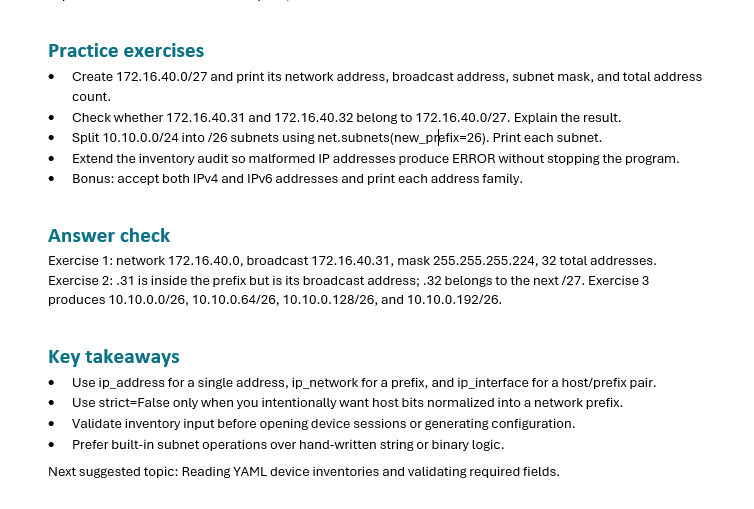



•	Create 172.16.40.0/27 and print its network address, broadcast address, subnet mask, and total address count.

In [20]:
import ipaddress

net1 = ip_network("172.16.40.0/27")
print(net1.network_address)
print(net1.broadcast_address)
print(net1.netmask)
print(net1.num_addresses)


172.16.40.0
172.16.40.31
255.255.255.224
32


In [21]:
import ipaddress

net1 = ipaddress.ip_network("172.16.40.0/27")

print(net1.network_address)
print(net1.broadcast_address)
print(net1.netmask)
print(net1.num_addresses)

172.16.40.0
172.16.40.31
255.255.255.224
32


In [22]:
from ipaddress import ip_network

net1 = ip_network("172.16.40.0/27")

print(f"Network Address : {net1.network_address}")
print(f"Broadcast Address: {net1.broadcast_address}")
print(f"Subnet Mask     : {net1.netmask}")
print(f"Total Addresses : {net1.num_addresses}")

Network Address : 172.16.40.0
Broadcast Address: 172.16.40.31
Subnet Mask     : 255.255.255.224
Total Addresses : 32


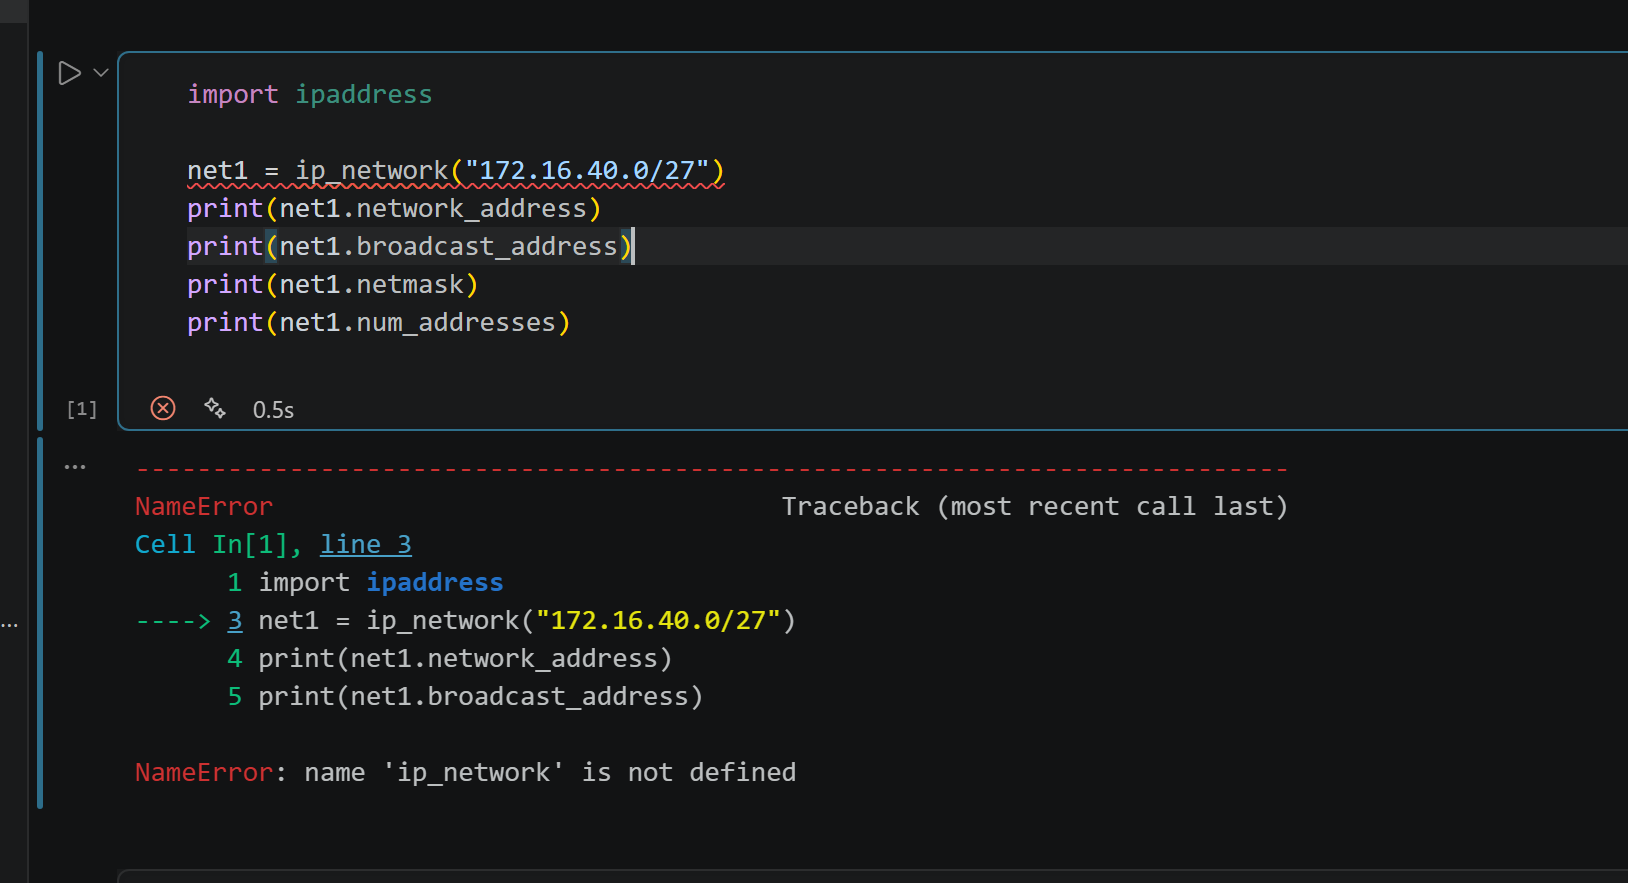

Your logic is **correct**, but the code in the screenshot has **one issue**.

### Issue ❌

You imported the module:

```python
import ipaddress
```

but then used:

```python
ip_network("172.16.40.0/27")
```

Since you imported the entire module, Python expects:

```python
ipaddress.ip_network("172.16.40.0/27")
```

Otherwise you'll get:

```python
NameError: name 'ip_network' is not defined
```

***

### Correct Version 1

```python
import ipaddress

net1 = ipaddress.ip_network("172.16.40.0/27")

print(net1.network_address)
print(net1.broadcast_address)
print(net1.netmask)
print(net1.num_addresses)
```

Output:

```text
172.16.40.0
172.16.40.31
255.255.255.224
32
```

***

### Correct Version 2 (Cleaner)

Import only what you need:

```python
from ipaddress import ip_network

net1 = ip_network("172.16.40.0/27")

print(net1.network_address)
print(net1.broadcast_address)
print(net1.netmask)
print(net1.num_addresses)
```

***

### Interview/Assignment-Friendly Version ⭐

```python
from ipaddress import ip_network

net1 = ip_network("172.16.40.0/27")

print(f"Network Address : {net1.network_address}")
print(f"Broadcast Address: {net1.broadcast_address}")
print(f"Subnet Mask     : {net1.netmask}")
print(f"Total Addresses : {net1.num_addresses}")
```

Output:

```text
Network Address : 172.16.40.0
Broadcast Address: 172.16.40.31
Subnet Mask     : 255.255.255.224
Total Addresses : 32
```

***

### Extra Improvement

Many networking interviews also ask for **usable host count**:

```python
usable_hosts = net1.num_addresses - 2

print(f"Usable Hosts    : {usable_hosts}")
```

Output:

```text
Usable Hosts    : 30
```

For a `/27` subnet:

* Network Address = `172.16.40.0`
* First Host = `172.16.40.1`
* Last Host = `172.16.40.30`
* Broadcast = `172.16.40.31`
* Total Addresses = `32`
* Usable Hosts = `30`

So your subnet calculations are **100% correct**. The only thing to verify is whether your actual code used:

```python
from ipaddress import ip_network
```

or

```python
import ipaddress
```

because the function call must match the import style.




•	Check whether 172.16.40.31 and 172.16.40.32 belong to 172.16.40.0/27. Explain the result.

In [26]:
from ipaddress import ip_address, ip_network

check_ip_address = ip_address("172.16.40.31")
#check_ip_address = ip_address("172.16.40.31", "172.16.40.32")
main_address = ip_network("172.16.40.0/27")

if check_ip_address in main_address:
    print("address present")
else:
    print("address not present")

address present


In [27]:
from ipaddress import ip_address, ip_network

#check_ip_address = ip_address("172.16.40.31")
check_ip_address = ip_address("172.16.40.31", "172.16.40.32")
main_address = ip_network("172.16.40.0/27")

if check_ip_address in main_address:
    print("address present")
else:
    print("address not present")

TypeError: ip_address() takes 1 positional argument but 2 were given

In [28]:
from ipaddress import ip_address, ip_network

network = ip_network("172.16.40.0/27")

ips = [
    "172.16.40.31",
    "172.16.40.32"
]

for value in ips:
    ip = ip_address(value)

    if ip in network:
        print(f"{ip} is inside {network}")
    else:
        print(f"{ip} is outside {network}")

172.16.40.31 is inside 172.16.40.0/27
172.16.40.32 is outside 172.16.40.0/27


In [29]:
from ipaddress import ip_address

ips = [
    "172.16.40.31",
    "172.16.40.32",
    "172.16.999.1"
]

for value in ips:
    try:
        print(ip_address(value))
    except ValueError as error:
        print(f"Invalid IP: {value} -> {error}")

172.16.40.31
172.16.40.32
Invalid IP: 172.16.999.1 -> '172.16.999.1' does not appear to be an IPv4 or IPv6 address


In [30]:
from ipaddress import ip_address, ip_network

network = ip_network("172.16.40.0/27")

for ip_str in ["172.16.40.31", "172.16.40.32"]:
    ip = ip_address(ip_str)

    print(f"\nIP Address : {ip}")
    print(f"In Network : {ip in network}")

    if ip in network:
        print("Result     : Member of subnet")
    else:
        print("Result     : Outside subnet")


IP Address : 172.16.40.31
In Network : True
Result     : Member of subnet

IP Address : 172.16.40.32
In Network : False
Result     : Outside subnet


In [35]:
from ipaddress import ip_address, ip_network

network = ip_network("172.16.40.0/27")

ips = [
    "172.16.40.31",
    "172.16.40.32",
    "172.16.999.1"
]

for value in ips:
    try:
        ip = ip_address(value)

        if ip in network:
            print(f"PASS : {ip} belongs to {network}")
        else:
            print(f"FAIL : {ip} does not belong to {network}")

    except ValueError as error:
        print(f"INVALID : {value} -> {error}")

PASS : 172.16.40.31 belongs to 172.16.40.0/27
FAIL : 172.16.40.32 does not belong to 172.16.40.0/27
INVALID : 172.16.999.1 -> '172.16.999.1' does not appear to be an IPv4 or IPv6 address
